### lesson \#23 by Storchak Vasyl

In [249]:
import platform
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from mango import scheduler, Tuner
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from prophet import Prophet
from xgboost import XGBRegressor
from chronos import BaseChronosPipeline

2025-08-15 23:08:37.748722: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755288517.820504   39704 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755288517.835837   39704 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755288517.967375   39704 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1755288517.967391   39704 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1755288517.967392   39704 computation_placer.cc:177] computation placer alr

In [ ]:
# load data & prep.

In [2]:
df = pd.read_csv('electricity_consumption_and_production.csv')

In [16]:
df['DateTime'] = pd.to_datetime(df['DateTime'])

In [22]:
df['Year'] = df['DateTime'].dt.year
df['Month'] = df['DateTime'].dt.month
df['Day'] = df['DateTime'].dt.day
df['Hour'] = df['DateTime'].dt.hour

In [49]:
df = df.set_index('DateTime')

In [7]:
# EDA

In [17]:
print("Shape:", df.shape)
print("\ninfo:")
df.info()
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())
print("\nSummary statistics:\n", df.describe())

Shape: (54161, 10)

info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54161 entries, 0 to 54160
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   DateTime       54161 non-null  datetime64[ns]
 1   Consumption    54161 non-null  int64         
 2   Production     54161 non-null  int64         
 3   Nuclear        54161 non-null  int64         
 4   Wind           54161 non-null  int64         
 5   Hydroelectric  54161 non-null  int64         
 6   Oil and Gas    54161 non-null  int64         
 7   Coal           54161 non-null  int64         
 8   Solar          54161 non-null  int64         
 9   Biomass        54161 non-null  int64         
dtypes: datetime64[ns](1), int64(9)
memory usage: 4.1 MB

Data types:
 DateTime         datetime64[ns]
Consumption               int64
Production                int64
Nuclear                   int64
Wind                      int64
Hydroelectric         

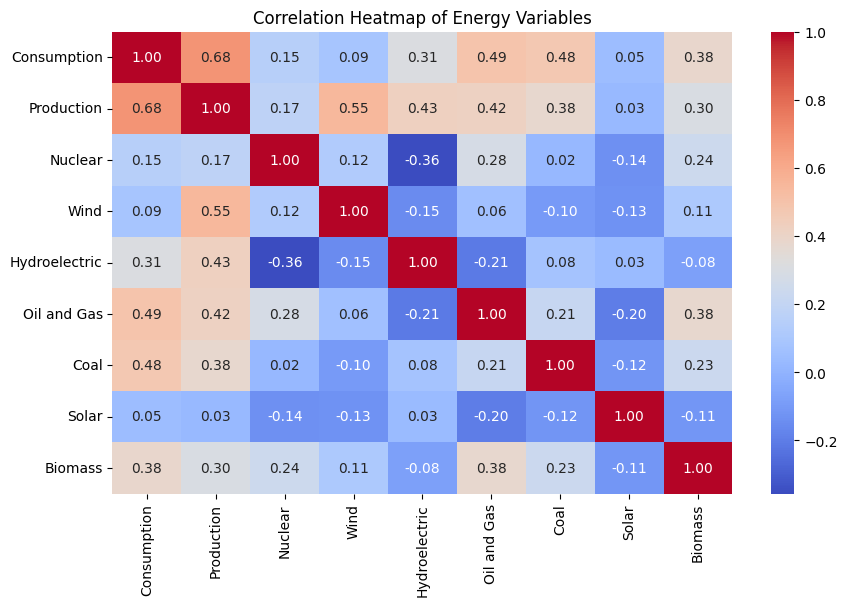

In [18]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.drop(columns=['DateTime']).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Energy Variables")
plt.show()

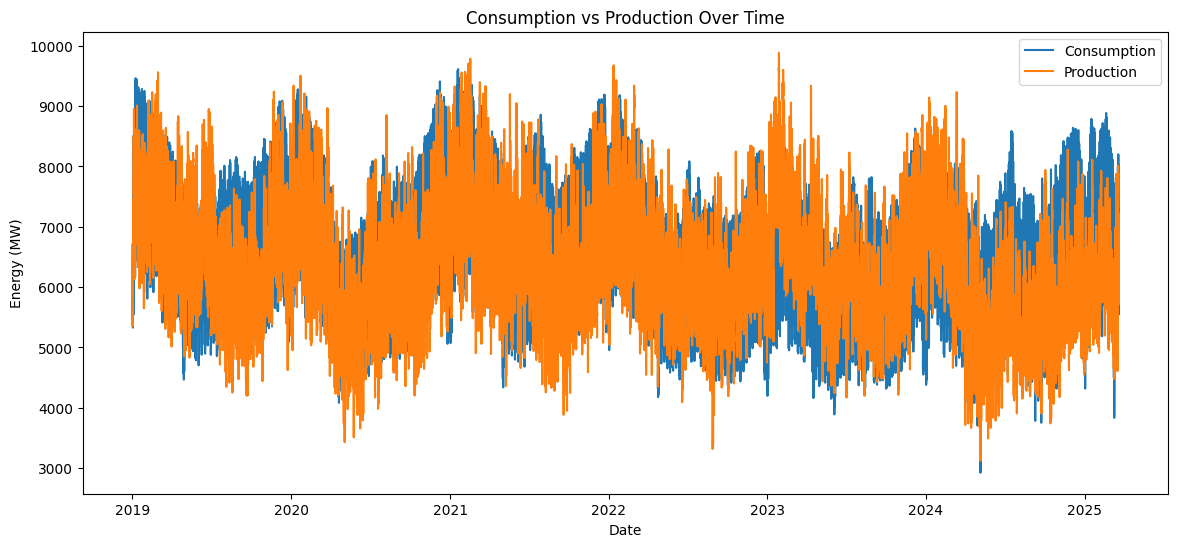

In [19]:
plt.figure(figsize=(14, 6))
plt.plot(df['DateTime'], df['Consumption'], label='Consumption')
plt.plot(df['DateTime'], df['Production'], label='Production')
plt.xlabel("Date")
plt.ylabel("Energy (MW)")
plt.title("Consumption vs Production Over Time")
plt.legend()
plt.show()

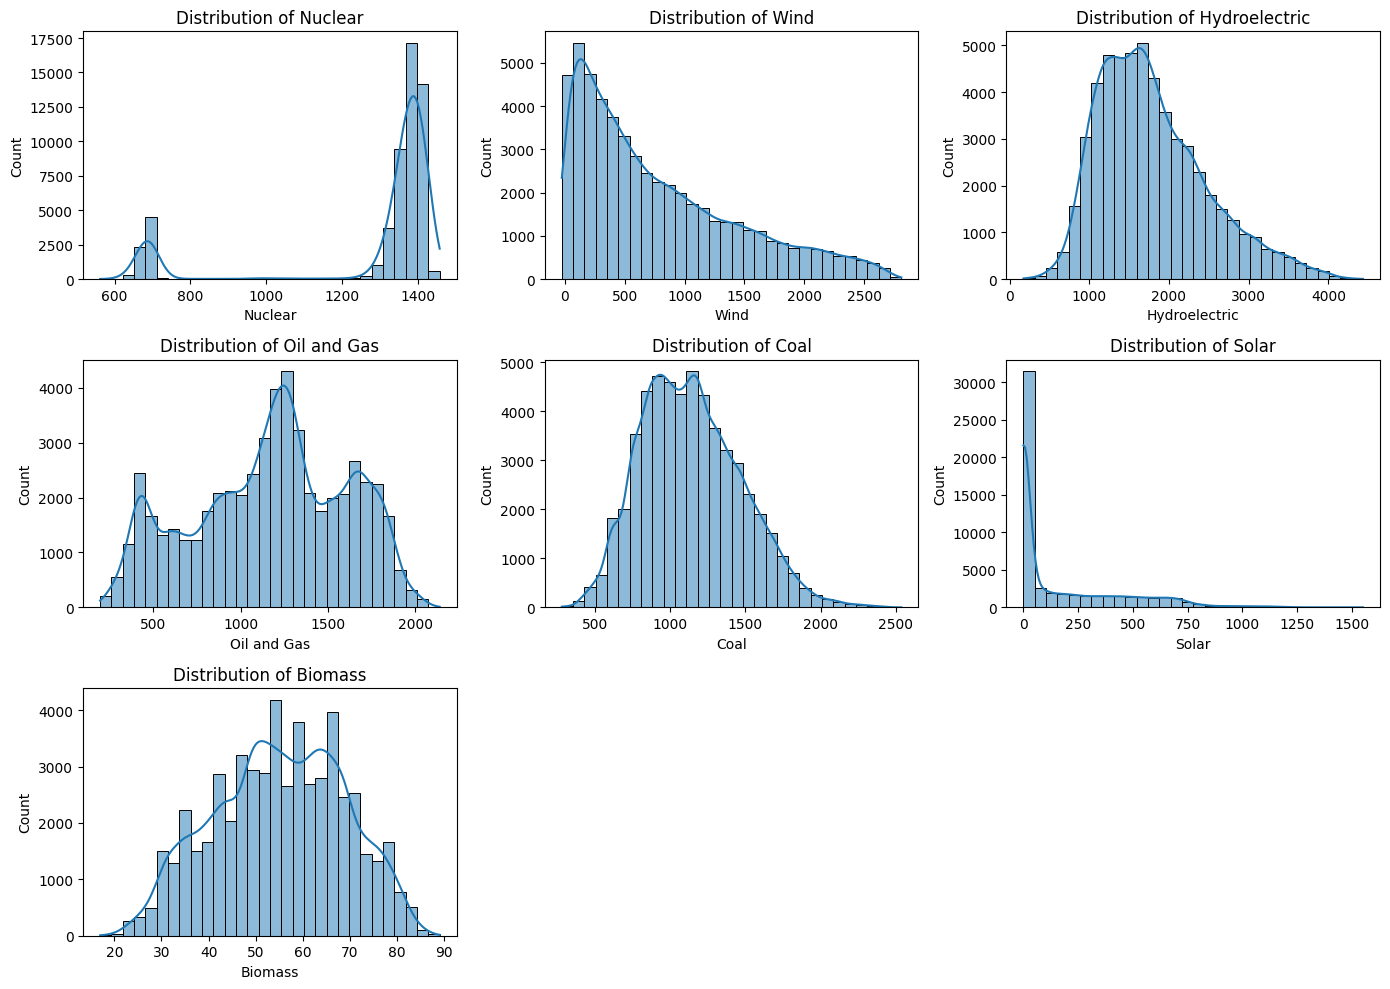

In [20]:
energy_sources = ['Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass']
plt.figure(figsize=(14, 10))
for i, col in enumerate(energy_sources, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

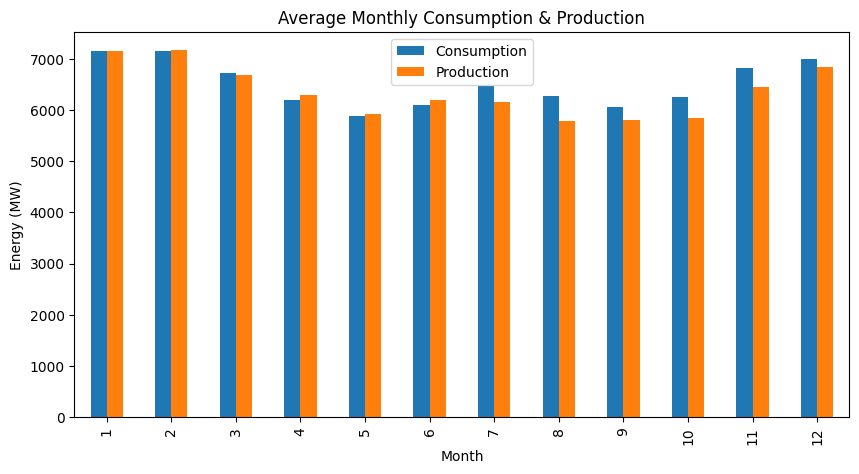

In [23]:
monthly_avg = df.groupby('Month')[['Consumption', 'Production']].mean()
monthly_avg.plot(kind='bar', figsize=(10, 5))
plt.title("Average Monthly Consumption & Production")
plt.ylabel("Energy (MW)")
plt.show()

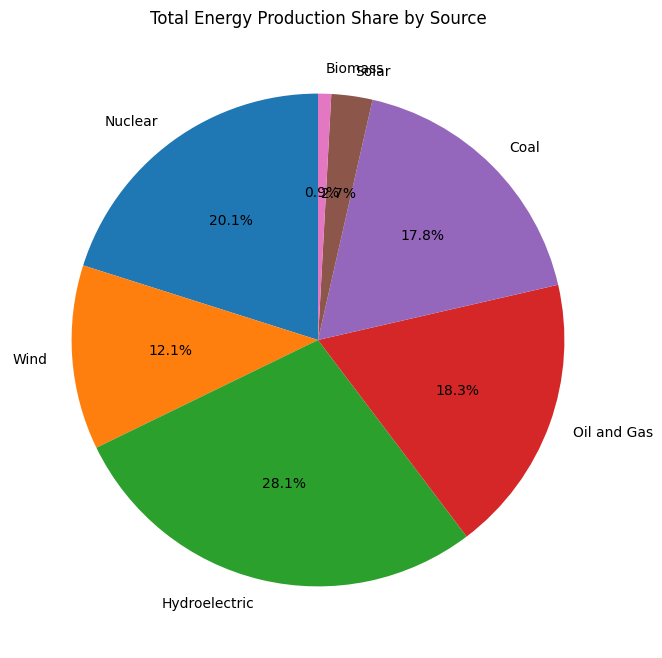

In [24]:
total_energy = df[energy_sources].sum()
plt.figure(figsize=(8, 8))
plt.pie(total_energy, labels=energy_sources, autopct='%1.1f%%', startangle=90)
plt.title("Total Energy Production Share by Source")
plt.show()

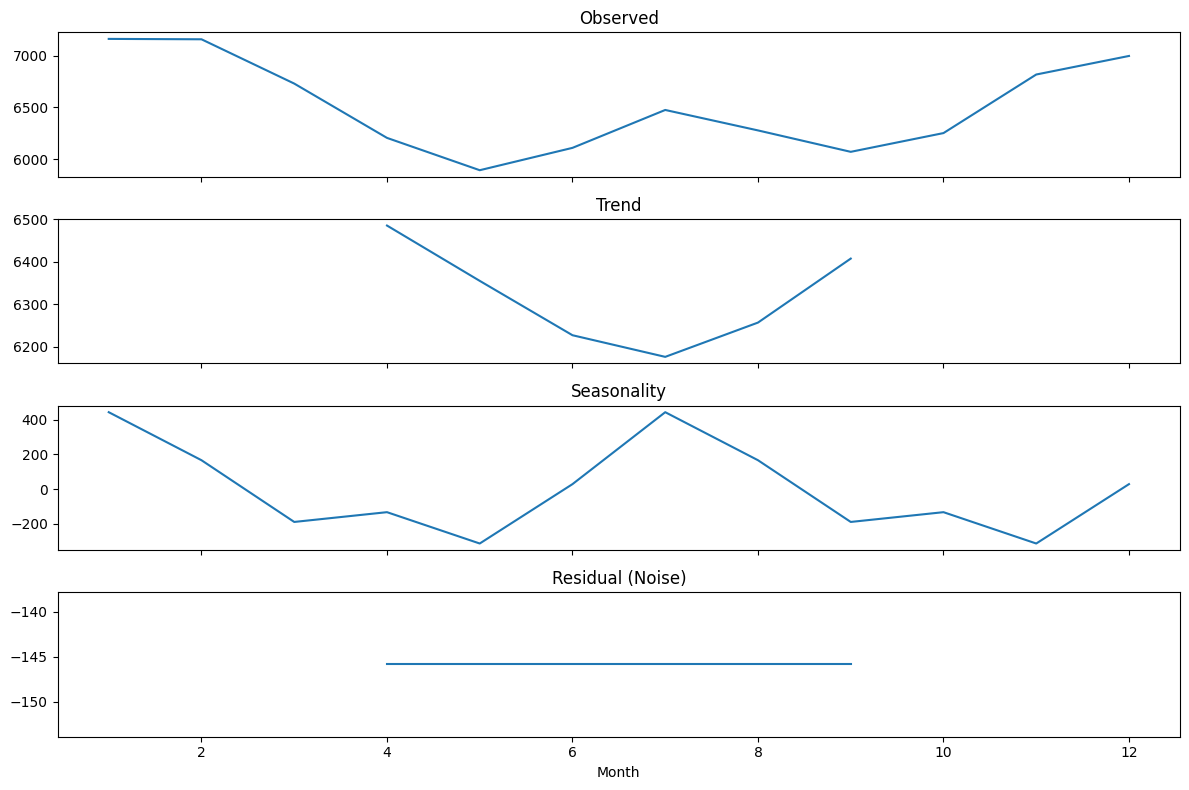

In [32]:
# for Consumption
decomposition = seasonal_decompose(monthly_avg['Consumption'], model='additive', period=6)

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonality')
decomposition.resid.plot(ax=axes[3], title='Residual (Noise)')
plt.tight_layout()

plt.show()

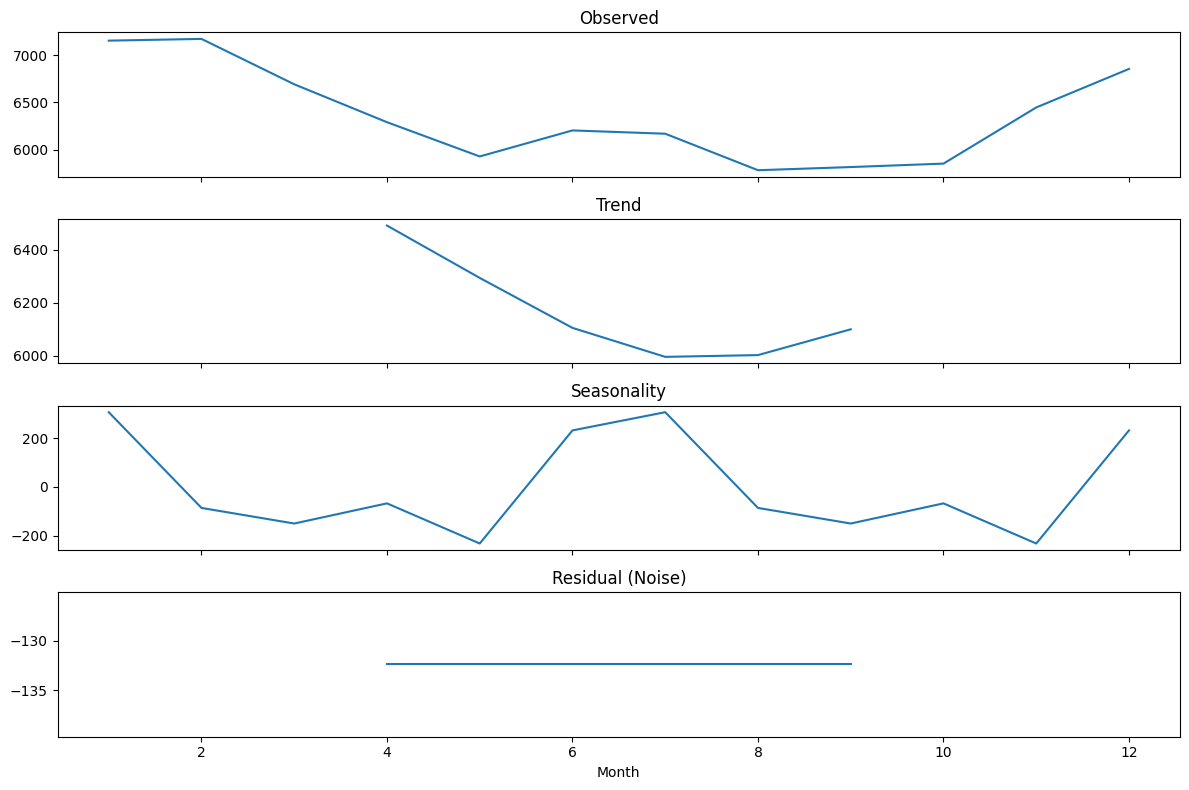

In [33]:
# for Production
decomposition = seasonal_decompose(monthly_avg['Production'], model='additive', period=6)

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonality')
decomposition.resid.plot(ax=axes[3], title='Residual (Noise)')
plt.tight_layout()

plt.show()

In [50]:
df_yearly = df.resample('Y').mean()

/tmp/ipykernel_39704/482615187.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_yearly = df.resample('Y').mean()


In [52]:
df_yearly.head()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,Year,Month,Day,Hour
DateTime,,,,,,,,,,,,,
2019-12-31,6859.475968,6692.099897,1287.845759,763.600297,1788.331202,1063.411462,1581.591049,157.307341,49.116794,2019.0,6.528485,15.724284,11.499258
2020-12-31,6622.517473,6312.619806,1307.752419,784.909050,1756.717928,1158.428685,1095.391007,153.942060,54.427205,2020.0,6.514855,15.757427,11.499032
2021-12-31,6956.352928,6715.109120,1290.701290,741.295286,1992.391508,1223.479740,1251.286954,147.716357,67.076361,2021.0,6.527223,15.722634,11.499030
2022-12-31,6425.775939,6301.651638,1268.456341,786.053647,1606.837918,1212.446753,1204.683141,157.880265,64.124872,2022.0,6.527223,15.722520,11.499030
2023-12-31,6088.096461,6450.820091,1279.377968,837.752626,2098.172032,1095.506849,930.610502,168.053311,44.273744,2023.0,6.526826,15.720890,11.500000


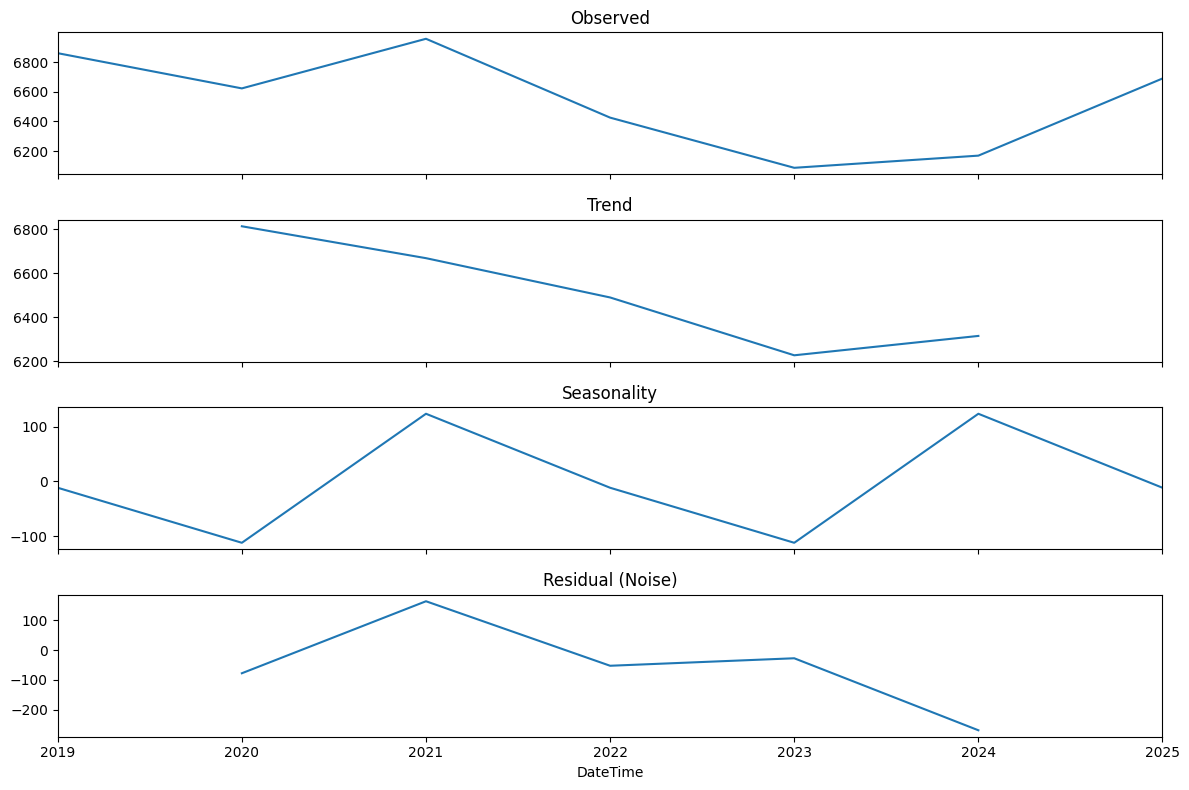

In [56]:
# for each year
decomposition = seasonal_decompose(df_yearly['Consumption'], model='additive', period=3)

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonality')
decomposition.resid.plot(ax=axes[3], title='Residual (Noise)')
plt.tight_layout()

plt.show()

In [93]:
# winter = 0, spring = 1, summer = 2, autumn = 3
season_map = {
    12: 0, 1: 0, 2: 0,
    3: 1, 4: 1, 5: 1,
    6: 2, 7: 2, 8: 2,
    9: 3, 10: 3, 11: 3
}

In [94]:
df['Season'] = df['Month'].map(season_map)

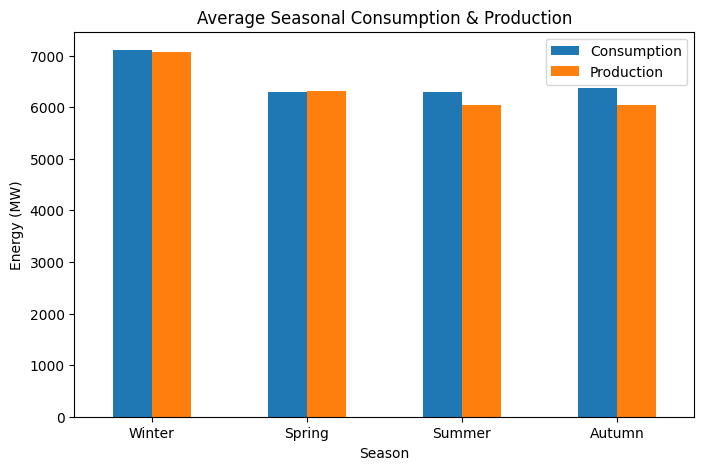

In [60]:
season_avg = df.groupby('Season')[['Consumption', 'Production']].mean()
season_avg = season_avg.reindex(['Winter', 'Spring', 'Summer', 'Autumn'])

season_avg.plot(kind='bar', figsize=(8, 5))

plt.title("Average Seasonal Consumption & Production")
plt.ylabel("Energy (MW)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
#########################################################################################################################################

In [3]:
# sarimax

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 54161 entries, 2019-01-01 00:00:00 to 2025-03-19 23:00:00
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Consumption    54161 non-null  int64 
 1   Production     54161 non-null  int64 
 2   Nuclear        54161 non-null  int64 
 3   Wind           54161 non-null  int64 
 4   Hydroelectric  54161 non-null  int64 
 5   Oil and Gas    54161 non-null  int64 
 6   Coal           54161 non-null  int64 
 7   Solar          54161 non-null  int64 
 8   Biomass        54161 non-null  int64 
 9   Year           54161 non-null  int32 
 10  Month          54161 non-null  int32 
 11  Day            54161 non-null  int32 
 12  Hour           54161 non-null  int32 
 13  Season         54161 non-null  object
dtypes: int32(4), int64(9), object(1)
memory usage: 5.4+ MB


In [95]:
test_size = 12 # use last 12 months as testing data
df_mon = df.resample('M').mean()
train_series, test_series = df_mon[:-test_size], df_mon[-test_size:]

In [239]:
df_mon

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,Year,Month,Day,Hour,Season
DateTime,,,,,,,,,,,,,,
2019-01-31,7755.416442,7370.159030,1381.808625,1068.981132,1323.952830,1748.370620,1744.370620,47.397574,54.447439,2019.0,1.0,16.035040,11.502695,0.0
2019-02-28,7605.071429,7625.120536,1381.049107,957.477679,1700.400298,1661.077381,1742.522321,123.056548,58.491071,2019.0,2.0,14.500000,11.500000,0.0
2019-03-31,6992.792732,7048.169583,1381.134590,886.218035,1795.557201,1102.156124,1638.699865,191.078062,52.717362,2019.0,3.0,15.979812,11.511440,1.0
2019-04-30,6652.491667,6707.433333,1377.844444,865.201389,1957.893056,615.155556,1656.720833,187.131944,46.291667,2019.0,4.0,15.500000,11.500000,1.0
2019-05-31,6379.282258,6705.147849,726.547043,729.064516,3106.077957,471.567204,1442.755376,193.776882,34.158602,2019.0,5.0,16.000000,11.500000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-30,6763.434783,5863.349275,1370.276812,756.417391,1209.802899,1478.971014,859.734783,140.271014,40.539130,2024.0,11.0,15.489855,11.500000,3.0
2024-12-31,6816.322581,6043.537167,1372.373072,1010.103787,1210.676017,1559.037868,782.925666,60.333801,40.750351,2024.0,12.0,16.152875,11.440393,0.0
2025-01-31,6678.596443,5933.904241,1375.402189,666.333789,1170.038304,1666.614227,876.487004,120.525308,50.284542,2025.0,1.0,16.013680,11.432285,0.0


In [96]:
len(train_series), len(test_series)

(63, 12)

In [148]:
train_series.shape

(63, 14)

In [97]:
train_series.head()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,Year,Month,Day,Hour,Season
DateTime,,,,,,,,,,,,,,
2019-01-31,7755.416442,7370.159030,1381.808625,1068.981132,1323.952830,1748.370620,1744.370620,47.397574,54.447439,2019.0,1.0,16.035040,11.502695,0.0
2019-02-28,7605.071429,7625.120536,1381.049107,957.477679,1700.400298,1661.077381,1742.522321,123.056548,58.491071,2019.0,2.0,14.500000,11.500000,0.0
2019-03-31,6992.792732,7048.169583,1381.134590,886.218035,1795.557201,1102.156124,1638.699865,191.078062,52.717362,2019.0,3.0,15.979812,11.511440,1.0
2019-04-30,6652.491667,6707.433333,1377.844444,865.201389,1957.893056,615.155556,1656.720833,187.131944,46.291667,2019.0,4.0,15.500000,11.500000,1.0
2019-05-31,6379.282258,6705.147849,726.547043,729.064516,3106.077957,471.567204,1442.755376,193.776882,34.158602,2019.0,5.0,16.000000,11.500000,1.0


In [98]:
test_series.describe()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,Year,Month,Day,Hour,Season
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,6204.245906,5625.703345,1240.742983,661.940391,1419.828675,1151.893083,837.215331,258.077813,50.496121,2024.250000,6.500000,15.225269,11.417532,1.500000
std,541.673279,417.293535,215.772832,157.993682,315.500047,400.354675,131.692645,103.629151,7.919279,0.452267,3.605551,1.718702,0.082972,1.167748
min,5400.153631,4806.921788,697.795804,462.316940,1127.412568,429.800279,623.300836,60.333801,40.539130,2024.000000,1.000000,9.917431,11.296089,0.000000
25%,5853.319078,5412.479662,1239.878071,559.562109,1206.663080,1019.485226,779.561813,200.222583,46.293340,2024.000000,3.750000,15.482077,11.337688,0.750000
50%,6083.339242,5582.673153,1354.636068,671.818705,1248.883453,1149.235301,811.391011,289.322193,49.619330,2024.000000,6.500000,15.683313,11.436339,1.500000
75%,6699.806028,5880.988017,1368.471192,743.147195,1550.022553,1496.353261,883.403015,326.159344,53.344832,2024.250000,9.250000,16.010661,11.476399,2.250000
max,7089.301136,6358.600379,1375.402189,1010.103787,2026.760446,1666.614227,1153.354167,387.285517,64.950758,2025.000000,12.000000,16.152875,11.529817,3.000000


In [206]:
@scheduler.parallel(n_jobs=16)
def sarima_objective(**params):
    try:
        model = SARIMAX(endog=train_series['Consumption'], 
                        order=(p, d, q), 
                        seasonal_order=(P, D, Q, s),
                        enforce_stationarity=False, 
                        enforce_invertibility=False)
        results = model.fit(disp=False)
        aic = results.aic # Minimize AIC to find the best model
    except:
        return 1e9
        # shit
        # aic = np.inf
    return aic

In [207]:
# Define the search space
sarimax_param_space = {
    'p': range(0, 3),
    'd': [1], # Use only first-order differencing
    'q': range(0, 3),
    'P': range(0, 3),
    'D': [1], # Use only first-order differencing
    'Q': range(0, 3),
    's': [12]  # Assume yearly seasonality
}

In [208]:
tuner = Tuner(sarimax_param_space, 
              objective=sarima_objective, 
              conf_dict={"num_iteration": 10})

In [209]:
tuning_results = tuner.minimize()

  0%|          | 0/10 [00:00<?, ?it/s]

In [210]:
best_params = tuning_results["best_params"]
best_params

{'s': 12, 'q': 1, 'p': 1, 'd': 1, 'Q': 2, 'P': 1, 'D': 1}

In [211]:
train_series.shape

(63, 14)

In [212]:
order = (
    [best_params["p"], best_params["p"], best_params["p"]],
    best_params["d"],
    [best_params["q"], best_params["q"], best_params["q"]],
)

seasonal_order = (
    best_params["P"], 
    best_params["D"],
    best_params["Q"],
    best_params["s"],
)

In [213]:
train_series.head()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,Year,Month,Day,Hour,Season
DateTime,,,,,,,,,,,,,,
2019-01-31,7755.416442,7370.159030,1381.808625,1068.981132,1323.952830,1748.370620,1744.370620,47.397574,54.447439,2019.0,1.0,16.035040,11.502695,0.0
2019-02-28,7605.071429,7625.120536,1381.049107,957.477679,1700.400298,1661.077381,1742.522321,123.056548,58.491071,2019.0,2.0,14.500000,11.500000,0.0
2019-03-31,6992.792732,7048.169583,1381.134590,886.218035,1795.557201,1102.156124,1638.699865,191.078062,52.717362,2019.0,3.0,15.979812,11.511440,1.0
2019-04-30,6652.491667,6707.433333,1377.844444,865.201389,1957.893056,615.155556,1656.720833,187.131944,46.291667,2019.0,4.0,15.500000,11.500000,1.0
2019-05-31,6379.282258,6705.147849,726.547043,729.064516,3106.077957,471.567204,1442.755376,193.776882,34.158602,2019.0,5.0,16.000000,11.500000,1.0


In [214]:
model = SARIMAX(train_series['Consumption'], order=order, seasonal_order=seasonal_order)

In [215]:
results = model.fit(disp=False)

In [216]:
forecast_series = results.forecast(steps=len(test_series))
forecast_series

2024-04-30    5853.954953
2024-05-31    5447.445080
2024-06-30    5478.075383
2024-07-31    5812.927199
2024-08-31    5748.495740
2024-09-30    5484.950302
2024-10-31    5464.573228
2024-11-30    6001.196736
2024-12-31    6232.822174
2025-01-31    6345.588446
2025-02-28    6316.187469
2025-03-31    5923.182323
Freq: ME, Name: predicted_mean, dtype: float64

In [224]:
test_series['Consumption']

DateTime
2024-04-30    5731.161560
2024-05-31    5400.153631
2024-06-30    5900.493706
2024-07-31    6409.166897
2024-08-31    5894.038251
2024-09-30    5601.603399
2024-10-31    5944.462888
2024-11-30    6763.434783
2024-12-31    6816.322581
2025-01-31    6678.596443
2025-02-28    7089.301136
2025-03-31    6222.215596
Freq: ME, Name: Consumption, dtype: float64

In [ ]:
# sarimax metric & visualize

In [219]:
def calculate_metrics(test_series: pd.Series, forecast_series: pd.Series):
    """
    Calculate metrics for the forecasted values
    
    Args:
        test_series (pd.Series): Time Series for evaluation
        forecasted_series (pd.Series): Forecasted values

    Returns:
        - mape: Mean Absolute Percentage Error between test vs forecast
        - mae: Mean Absolute Error between test vs forecast 
        - mse: Mean Squared Error between test vs forecast 
    """

    mape = mean_absolute_percentage_error(test_series, forecast_series)
    mae = mean_absolute_error(test_series, forecast_series)
    mse = mean_squared_error(test_series, forecast_series)

    return mape, mae, mse


def visualize_forecast(
    train_series: pd.Series,
    test_series: pd.Series, 
    forecast_series: pd.Series,
    title: str="Forecasting predictions"
):
    """
    Visualize forecasting predictions with metrics
    
    Args:
        train_series (pd.Series): Historircal time series
        test_series (pd.Series): Time Series for evaluation
        forecasted_series (pd.Series): Forecasted values
        title (str): Plot title
    """

    # Calculate metrics
    mape, mae, mse = calculate_metrics(test_series, forecast_series)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Plot each series
    train_series.plot(ax=ax, label="Train series")
    test_series.plot(ax=ax, label="Test Series")
    forecast_series.plot(ax=ax, label="Predicted Series")
    
    # Plotting titles and labels
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Forecast results")
    ax.grid(True)
    ax.legend(title="Series")

    # Add the metrics as text on the plot
    metrics_text = f"MAPE: {mape:.2f}%\nMAE: {mae:.2f}\nMSE: {mse:.2f}"
    ax.text(0.99, 0.95, metrics_text, transform=ax.transAxes, 
            fontsize=12, verticalalignment='top', horizontalalignment='right',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='black', boxstyle='round,pad=1'))

    plt.tight_layout()
    plt.show()

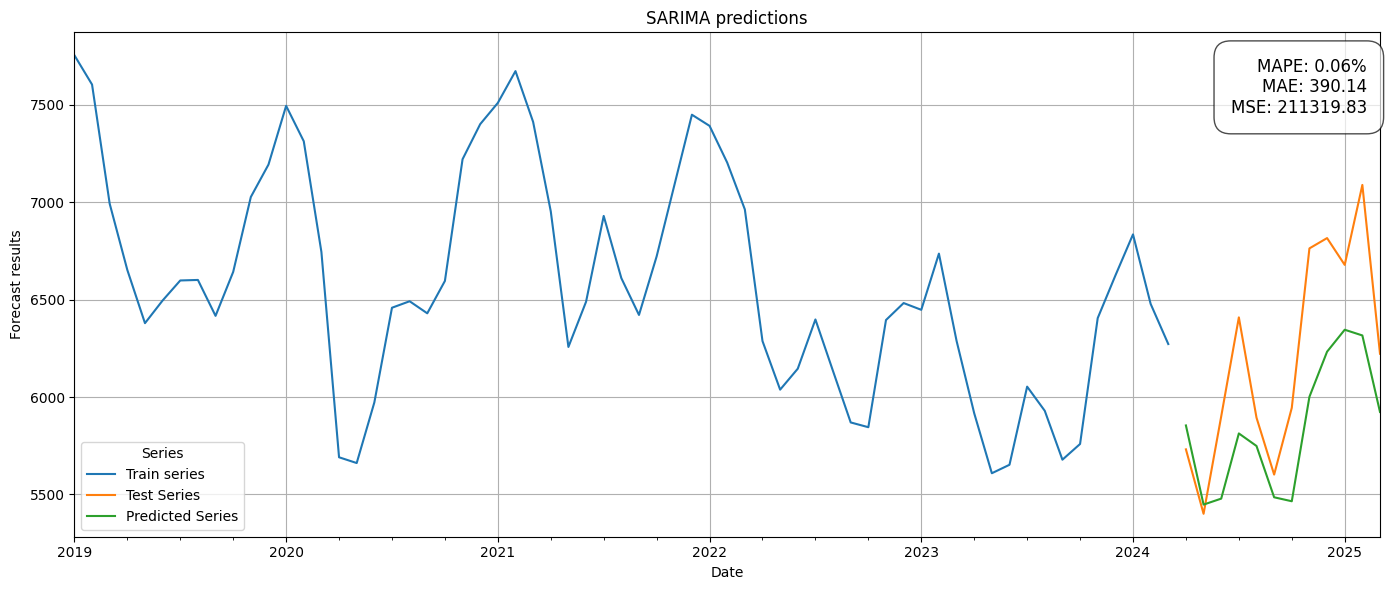

In [225]:
visualize_forecast(
    train_series['Consumption'],
    test_series['Consumption'],
    forecast_series,
    title="SARIMA predictions"
)

In [ ]:
# GOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOD 8-) 

In [ ]:
#########################################################################################################################################

In [4]:
# prophet

In [227]:
# Note: Prophet requires train_df in format: {"ds": <timestamps>, "y": <target_variable>}
train_df_prophet = pd.DataFrame({
    'ds': train_series['Consumption'].index, 
    'y': train_series['Consumption'].values 
})

In [228]:
model = Prophet()
model.fit(train_df_prophet)

22:57:21 - cmdstanpy - INFO - Chain [1] start processing
22:57:21 - cmdstanpy - INFO - Chain [1] done processing


In [229]:
future_df = model.make_future_dataframe(periods=len(test_series['Consumption']), include_history=False, freq='M')
future_df

,ds
0,2024-04-30
1,2024-05-31
2,2024-06-30
3,2024-07-31
4,2024-08-31
5,2024-09-30
6,2024-10-31
7,2024-11-30
8,2024-12-31
9,2025-01-31


In [230]:
forecast = model.predict(future_df)
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2024-04-30,5909.764853,5214.378956,5586.738696,5907.282292,5911.726605,-504.820733,-504.820733,-504.820733,-504.820733,-504.820733,-504.820733,0.0,0.0,0.0,5404.944119
1,2024-05-31,5887.066435,4930.351374,5285.949087,5877.505606,5894.594692,-783.539268,-783.539268,-783.539268,-783.539268,-783.539268,-783.539268,0.0,0.0,0.0,5103.527166
2,2024-06-30,5865.100224,5179.793878,5534.988528,5845.281141,5881.157837,-507.993876,-507.993876,-507.993876,-507.993876,-507.993876,-507.993876,0.0,0.0,0.0,5357.106348
3,2024-07-31,5842.401806,5595.628119,5950.390167,5810.317444,5869.254807,-58.166471,-58.166471,-58.166471,-58.166471,-58.166471,-58.166471,0.0,0.0,0.0,5784.235335
4,2024-08-31,5819.703388,5380.955954,5759.241663,5772.686698,5857.174616,-235.030282,-235.030282,-235.030282,-235.030282,-235.030282,-235.030282,0.0,0.0,0.0,5584.673106
5,2024-09-30,5797.737177,5206.486205,5593.786848,5734.340618,5848.154439,-392.103567,-392.103567,-392.103567,-392.103567,-392.103567,-392.103567,0.0,0.0,0.0,5405.633610
6,2024-10-31,5775.038759,5336.098420,5714.347953,5693.724839,5843.645782,-239.620291,-239.620291,-239.620291,-239.620291,-239.620291,-239.620291,0.0,0.0,0.0,5535.418468
7,2024-11-30,5753.072548,5808.918991,6221.418830,5650.181554,5838.387994,266.671690,266.671690,266.671690,266.671690,266.671690,266.671690,0.0,0.0,0.0,6019.744238
8,2024-12-31,5730.374130,6015.465420,6451.817881,5604.734216,5835.101293,502.822378,502.822378,502.822378,502.822378,502.822378,502.822378,0.0,0.0,0.0,6233.196508
9,2025-01-31,5707.675712,5980.199515,6429.886810,5559.631570,5826.921766,509.814241,509.814241,509.814241,509.814241,509.814241,509.814241,0.0,0.0,0.0,6217.489953


In [231]:
forecast_series = forecast.set_index('ds')['yhat']

In [ ]:
# prophet metric & visualize

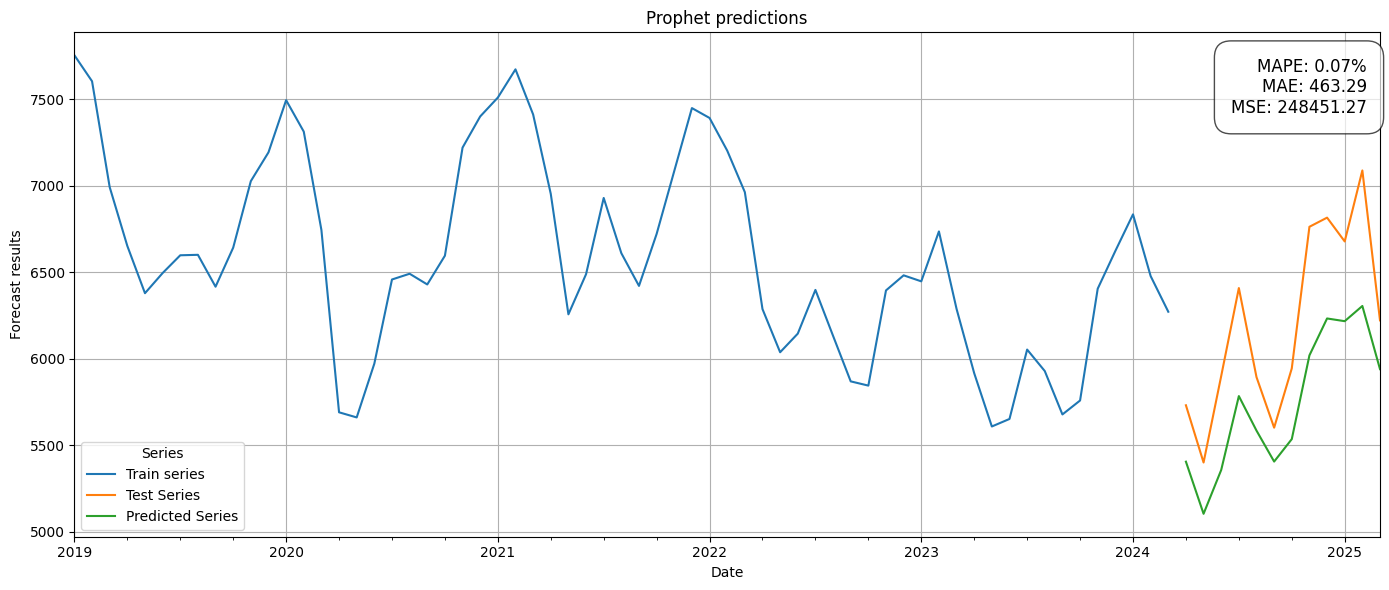

In [232]:
visualize_forecast(
    train_series=train_series['Consumption'],
    test_series=test_series['Consumption'],
    forecast_series=forecast_series,
    title="Prophet predictions"
)

In [ ]:
# some better like sarimex

In [ ]:
#########################################################################################################################################

In [5]:
# time lagged regression

In [235]:
def create_lag_features(time_series: pd.Series, lags=12):
    """Create time-lagged features for the provided time series"""

    df = pd.DataFrame(time_series)

    for i in range(1, lags + 1):
        df[f'lag_{i}'] = df.iloc[:, 0].shift(i)
    
    return df

In [237]:
monthly_avg

,Consumption,Production
Month,,
1,7160.448103,7151.925669
2,7156.700521,7170.343316
3,6729.449234,6690.746476
4,6205.544465,6290.300834
5,5893.723625,5928.202885
6,6109.424334,6203.239397
7,6474.965129,6168.536558
8,6277.639712,5782.838500
9,6071.090804,5816.234092


In [240]:
lags = 12 # Experiment with number of lags to improve model accuracy
time_lagged_df = create_lag_features(df_mon['Consumption'], lags)
time_lagged_df = time_lagged_df.dropna() # Remove rows with NaN values after applying shifting
time_lagged_df.tail(10)

,Consumption,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12
DateTime,,,,,,,,,,,,,
2024-06-30,5900.493706,5400.153631,5731.161560,6272.119624,6478.412356,6835.251344,6623.670699,6405.222222,5758.722148,5678.083333,5929.065860,6053.303763,5651.966667
2024-07-31,6409.166897,5900.493706,5400.153631,5731.161560,6272.119624,6478.412356,6835.251344,6623.670699,6405.222222,5758.722148,5678.083333,5929.065860,6053.303763
2024-08-31,5894.038251,6409.166897,5900.493706,5400.153631,5731.161560,6272.119624,6478.412356,6835.251344,6623.670699,6405.222222,5758.722148,5678.083333,5929.065860
2024-09-30,5601.603399,5894.038251,6409.166897,5900.493706,5400.153631,5731.161560,6272.119624,6478.412356,6835.251344,6623.670699,6405.222222,5758.722148,5678.083333
2024-10-31,5944.462888,5601.603399,5894.038251,6409.166897,5900.493706,5400.153631,5731.161560,6272.119624,6478.412356,6835.251344,6623.670699,6405.222222,5758.722148
2024-11-30,6763.434783,5944.462888,5601.603399,5894.038251,6409.166897,5900.493706,5400.153631,5731.161560,6272.119624,6478.412356,6835.251344,6623.670699,6405.222222
2024-12-31,6816.322581,6763.434783,5944.462888,5601.603399,5894.038251,6409.166897,5900.493706,5400.153631,5731.161560,6272.119624,6478.412356,6835.251344,6623.670699
2025-01-31,6678.596443,6816.322581,6763.434783,5944.462888,5601.603399,5894.038251,6409.166897,5900.493706,5400.153631,5731.161560,6272.119624,6478.412356,6835.251344
2025-02-28,7089.301136,6678.596443,6816.322581,6763.434783,5944.462888,5601.603399,5894.038251,6409.166897,5900.493706,5400.153631,5731.161560,6272.119624,6478.412356


In [241]:
train_df, test_df = time_lagged_df[:-test_size], time_lagged_df[-test_size:]

In [242]:
X_train = train_df.iloc[:, 1:]
y_train = train_df.iloc[:, 0]
X_test = test_df.iloc[:, 1:]
y_test = test_df.iloc[:, 0]

In [243]:
model = XGBRegressor()
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [244]:
y_pred = []
current_input = X_test.iloc[0].values.reshape(1, -1)

for _ in range(len(y_test)):
    prediction = model.predict(current_input)[0]
    y_pred.append(prediction)

    # Slide the window: Remove the oldest lag, add the latest prediction
    current_input = pd.concat([pd.Series([prediction]), pd.Series(current_input[0][:-1])]).values.reshape(1, -1)

In [245]:
len(y_pred)

12

In [246]:
forecast_series = pd.Series(y_pred, index=test_series.index)
forecast_series

DateTime
2024-04-30    5957.209473
2024-05-31    5769.245605
2024-06-30    5797.715820
2024-07-31    5962.255859
2024-08-31    5919.853027
2024-09-30    5743.643555
2024-10-31    5740.976562
2024-11-30    6167.371094
2024-12-31    6276.235352
2025-01-31    6050.859375
2025-02-28    5811.634277
2025-03-31    5799.401367
Freq: ME, dtype: float32

In [247]:
len(test_series), len(forecast_series)

(12, 12)

In [ ]:
# time lagged regression metric & visualize

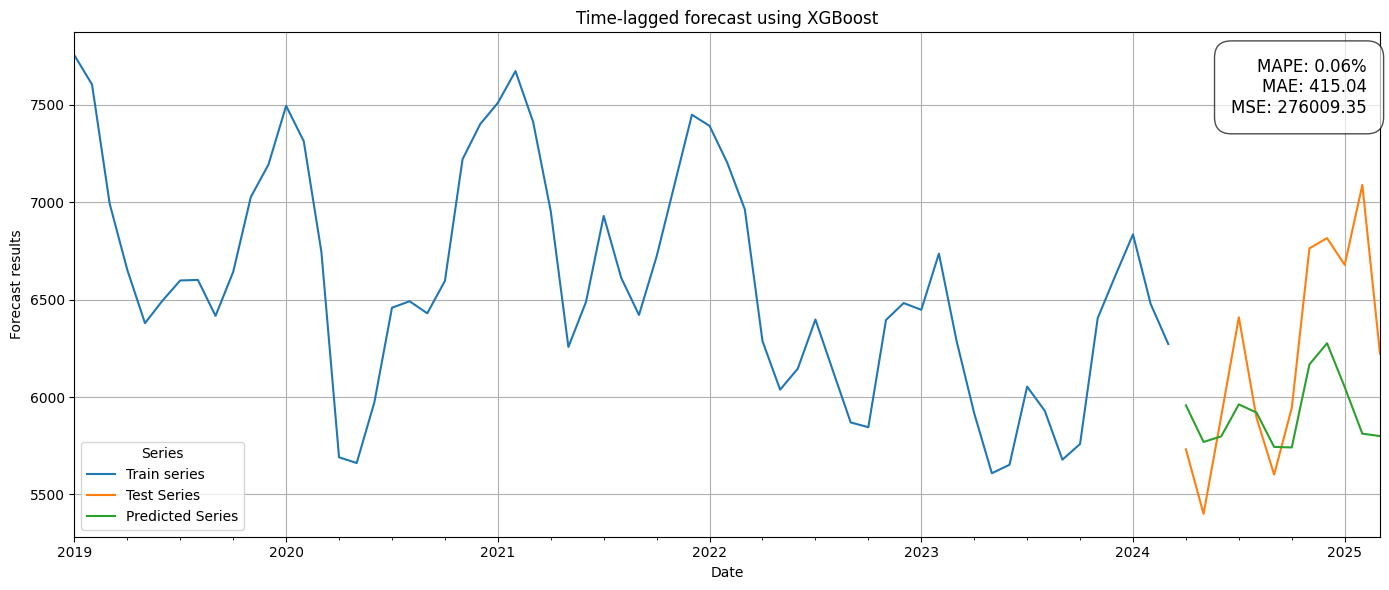

In [248]:
visualize_forecast(
    train_series['Consumption'],
    test_series['Consumption'],
    forecast_series,
    title="Time-lagged forecast using XGBoost"
)

In [ ]:
# some worst when prophet

In [ ]:
#########################################################################################################################################

In [6]:
# chronos bolt

In [254]:
chronos_model = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-bolt-base",
    device_map="cuda",
    torch_dtype=torch.float32,
)

In [255]:
train_values = torch.tensor(train_series['Consumption'])
forecast = chronos_model.predict_quantiles(
    context=train_values,
    prediction_length=len(test_series['Consumption'])
)

Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


In [ ]:
# chronos bolt metric & visualize

In [256]:
mean_forecast = forecast[1][0].tolist() # Target predictions (mean)
forecast_series = pd.Series(mean_forecast, index=test_series.index)
forecast_series.tail(10)

DateTime
2024-06-30    5704.811523
2024-07-31    5945.665039
2024-08-31    5916.112305
2024-09-30    5798.434570
2024-10-31    5891.277344
2024-11-30    6363.794922
2024-12-31    6619.862305
2025-01-31    6822.451660
2025-02-28    6723.450195
2025-03-31    6375.440918
Freq: ME, dtype: float64

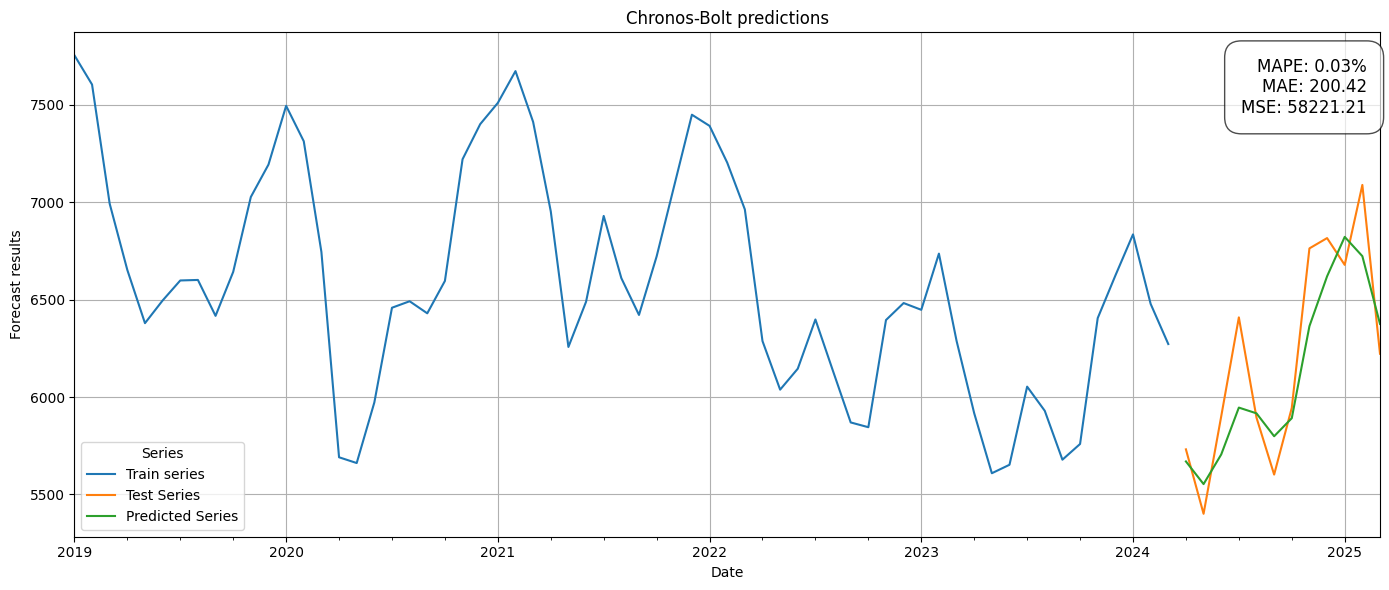

In [257]:
visualize_forecast(
    train_series=train_series['Consumption'],
    test_series=test_series['Consumption'],
    forecast_series=forecast_series,
    title="Chronos-Bolt predictions"
)

In [ ]:
# the best choise